# Full Sequence-to-Sequence Encoder-Decoder Transformer for Neural Machine Translation

## Team Members

| Name                   | Roll Number |
| ---------------------- | ----------- |
| Poonam Biswal          | 2024ac05803 |
| Vikas Mahadev Hiremath | 2023ad05081 |
| Praveen Kanwar         | 2024ac05746 |
| S Amina                | 2024ac05758 |

## Project

Neural Machine Translation using a full Encoder-Decoder Transformer implemented from scratch in PyTorch.

## 1. Introduction
This project implements a full Sequence-to-Sequence (Seq2Seq) Transformer from scratch using PyTorch. We avoid using `torch.nn.Transformer` or any pretrained models. The model learns to translate English to German by utilizing Encoder blocks for source representation and Decoder blocks equipped with Cross-Attention for target generation.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import torch
from src.config import DEVICE

print(f"Executing Notebook on Device: {DEVICE}")

Executing Notebook on Device: mps


## 2. Dataset Description
We use the `bentrevett/multi30k` dataset via Hugging Face. This dataset provides a collection of English-German parallel sentences, specifically describing images. It serves as an excellent benchmark for small-scale Machine Translation.

In [2]:
from src.data import load_and_preprocess_data

train_pairs, val_pairs, test_pairs = load_and_preprocess_data()
print(f"Training pairs: {len(train_pairs)}")
print(f"Validation pairs: {len(val_pairs)}")
print(f"Testing pairs: {len(test_pairs)}")

Training pairs: 29000
Validation pairs: 1014
Testing pairs: 1000


## 3. Task 1: Dual-Language Preprocessing
Data preprocessing is crucial. We apply Unicode Normalization (NFC) to safely preserve German specific characters (like ä, ö, ü, ß) instead of decomposing them. We also lowercase the text, separate punctuation, and remove empty sentences to maintain strict parallel alignment.

In [3]:
from src.data import preprocess_text

sample_en = "Hello World! This is an example."
sample_de = "Hallo Welt! Äpfel sind süß."

print(f"English Original: {sample_en}")
print(f"English Processed: {preprocess_text(sample_en)}\n")
print(f"German Original: {sample_de}")
print(f"German Processed: {preprocess_text(sample_de)}")

English Original: Hello World! This is an example.
English Processed: hello world ! this is an example .

German Original: Hallo Welt! Äpfel sind süß.
German Processed: hallo welt ! äpfel sind süß .


## 4. Task 2: Shared vs Separate Tokenizer Training
We utilize **separate** BPE (Byte-Pair Encoding) tokenizers for English and German.
**Technical Justification**: While English and German are related Germanic languages, German exhibits stronger compounding, different capitalization rules, and unique morphology. Training separate vocabularies ensures optimal subword segmentation for each language's specific phonetic and morphological structure. Tokenizers are trained *only* on the training split to prevent data leakage.

In [4]:
from src.tokenizer_train import get_or_train_tokenizers

src_tokenizer, tgt_tokenizer = get_or_train_tokenizers(train_pairs)
print(f"Source (English) Vocabulary Size: {src_tokenizer.get_vocab_size()}")
print(f"Target (German) Vocabulary Size: {tgt_tokenizer.get_vocab_size()}")

Loading existing tokenizers...
Source (English) Vocabulary Size: 8000
Target (German) Vocabulary Size: 8000


## 5. Task 3: Cross-Attention Mechanism
The core of our translation capability is the **Cross-Attention Mechanism** within the Decoder. It maps the translated sequence back to the original source.
- **Query (Q)**: Comes from the Decoder's hidden states (the target context we have generated so far).
- **Key (K)**: Comes from the Encoder's outputs (the source context).
- **Value (V)**: Comes from the Encoder's outputs (the source context).
This allows the decoder to "attend" or focus on the relevant parts of the English sentence when predicting the next German word.

In [5]:
import inspect
from src.transformer import DecoderLayer

# Extracting the source code for the forward pass of our DecoderLayer
# to show explicit Q, K, V routing.
source_code = inspect.getsource(DecoderLayer.forward)
for line in source_code.split('\n'):
    if "cross_attn_out" in line and "self.cross_attn" in line:
        print("Cross-Attention Implementation Found:\n")
        print(line.strip())

Cross-Attention Implementation Found:

cross_attn_out, _ = self.cross_attn(q=x, k=enc_output, v=enc_output, mask=src_mask)


## 6. Task 4: Positional and Padding Masking
Transformers process sequences in parallel and do not have an inherent sense of order.
1. **Source Padding Mask**: Hides `<pad>` tokens in the encoder so attention scores for padding are `-1e9`. Shape: `(batch_size, 1, 1, src_len)`.
2. **Causal Mask**: Prevents the decoder from looking into the "future" when predicting the next word. It is a lower triangular matrix.
3. **Target Combined Mask**: Merges target padding and the causal mask. Shape: `(batch_size, 1, tgt_len, tgt_len)`.

In [6]:
import torch
from src.masks import create_masks

dummy_src = torch.tensor([[1, 2, 3, 0, 0]]) # 0 is PAD_IDX
dummy_tgt = torch.tensor([[1, 4, 5, 6, 0]])

src_mask, tgt_mask = create_masks(dummy_src, dummy_tgt, torch.device("cpu"))

print("Source Padding Mask Shape:", src_mask.shape)
print("Source Padding Mask Values:\n", src_mask[0, 0, 0, :])
print("\nTarget Combined Mask Shape:", tgt_mask.shape)
print("Target Combined Mask Values:\n", tgt_mask[0, 0, :, :])

Source Padding Mask Shape: torch.Size([1, 1, 1, 5])
Source Padding Mask Values:
 tensor([ True,  True,  True, False, False])

Target Combined Mask Shape: torch.Size([1, 1, 5, 5])
Target Combined Mask Values:
 tensor([[ True, False, False, False, False],
        [ True,  True, False, False, False],
        [ True,  True,  True, False, False],
        [ True,  True,  True,  True, False],
        [ True,  True,  True,  True, False]])


## 7. Task 5: Training Loop with Teacher Forcing
We initialize the full `Seq2SeqTransformer`. We use **Teacher Forcing** during training, where the decoder receives the true previous target tokens (`tgt[:, :-1]`) and tries to predict the next true target tokens (`tgt[:, 1:]`). We optimize using Adam with a Noam Learning Rate Scheduler and calculate loss using `CrossEntropyLoss` (ignoring `<pad>` tokens).

In [7]:
import pandas as pd
from pathlib import Path

output_dir = Path("../outputs") if Path("../outputs").exists() else Path("outputs")
summary_file = output_dir / "training_summary.txt"

if summary_file.exists():
    with open(summary_file, "r") as f:
        print(f.read())
else:
    print("Run `python train.py` first to generate training statistics.")

Trainable parameters: 10,105,664\nFinal training loss: 2.1141\nFinal validation loss: 2.5044\nBest validation loss: 2.5044\n


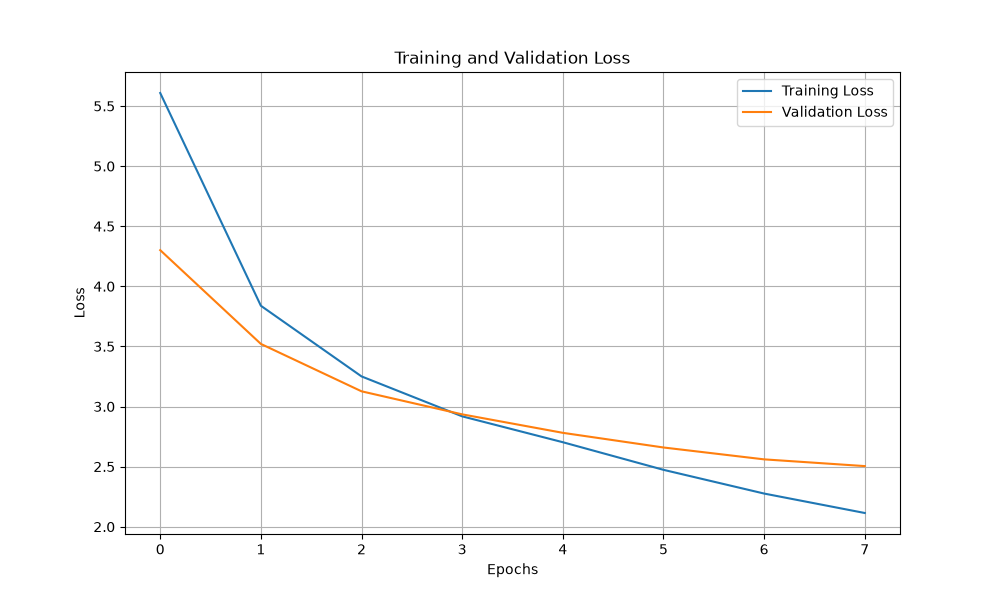

In [8]:
from IPython.display import Image, display

curve_path = output_dir / "training_curve.png"
if curve_path.exists():
    display(Image(filename=curve_path))
else:
    print("Run `python train.py` first to generate training curves.")

## 8. Task 6: Qualitative and Quantitative Translation Analysis
We evaluate our model using SacreBLEU, the industry standard. We test both Greedy Decoding (taking the single best word at each step) and Beam Search Decoding (keeping top-K paths to find a better global sentence).

In [9]:
bleu_file = output_dir / "bleu_score.txt"
if bleu_file.exists():
    with open(bleu_file, "r") as f:
        print(f.read())
else:
    print("Run `python evaluate.py` first to calculate BLEU scores.")

BLEU Score (Greedy Decoding): 22.60\nBLEU Score (Beam Decoding): 24.02\n


In [10]:
translations_file = output_dir / "sample_translations.csv"
if translations_file.exists():
    df = pd.read_csv(translations_file)
    pd.set_option('display.max_colwidth', None)
    # Display at least five examples
    display(df.sample(n=5, random_state=42))
else:
    print("Run `python evaluate.py` first to generate sample translations.")

,source_english,reference_german,greedy_translation,beam_translation,qualitative_comment
361,three boys wearing green shirts and tan pants pose at the top of a slide .,drei jungen in grünen shirts und braunen hosen posieren auf dem oberteil einer rutsche .,drei jungen in hellbraunen oberteilen posieren am fuß einer rutsche .,drei jungen in hellbraunen oberteilen posieren am fuß einer rutsche .,Acceptable translation: Partial semantic overlap; core meaning is somewhat captured but grammar may be flawed.
73,a female performer with a violin plays on a street while a woman with a blue guitar looks on .,eine musikantin mit einer violine spielt auf der straße während eine frau mit einer blauen gitarre zusieht .,eine frau mit einer blauen gitarre spielt auf einer straße und schaut dabei zu .,"eine frau mit einer blauen gitarre spielt gitarre auf einer straße , während ein anderer gitarre spielt .",Acceptable translation: Partial semantic overlap; core meaning is somewhat captured but grammar may be flawed.
374,a crowd gathered around a park water fountain in the rain .,eine menschenmenge hat sich im regen um einen springbrunnen im park versammelt .,eine menschenmenge versammelt sich im regen um einen brunnen versammelt .,eine menschenmenge versammelt sich um einen brunnen im wasser versammelt .,Good translation: High lexical overlap; meaning is well preserved with minor syntactic differences.
155,a girl jumping rope on a sidewalk near a parking garage .,ein mädchen beim seilhüpfen auf dem gehweg nahe einer garage .,ein mädchen auf einem parkplatz springt neben einem seil .,ein mädchen auf einem parkplatz springt neben einem seil .,Poor translation: Limited lexical overlap; captures only fragmented concepts.
104,a group of people are climbing in cold weather .,eine gruppe klettert bei kaltem wetter .,eine gruppe von menschen klettert in london hoch .,eine gruppe von menschen klettert in london hoch .,Acceptable translation: Partial semantic overlap; core meaning is somewhat captured but grammar may be flawed.


## 9. Why Full Encoder-Decoder Architecture is Required for NMT

| Architecture | Paradigm | Information Flow | Suitability for NMT |
|---|---|---|---|
| **Encoder-Only** | Auto-Encoding (e.g., BERT) | Bidirectional. Every token sees every other token. | Poor. Excellent for classification or NER, but lacks the autoregressive mechanism needed to generate sequences of variable length. |
| **Decoder-Only** | Autoregressive (e.g., GPT) | Unidirectional (Causal). Tokens only see the past. | Moderate. Can do translation via few-shot prompting, but mixes source and target context into a single masked representation, losing explicit structural mapping. |
| **Encoder-Decoder** | Sequence-to-Sequence (e.g., T5, BART, Ours) | Bidirectional Encoder + Unidirectional Decoder + Cross-Attention. | **Excellent**. The Encoder builds a rich, fully contextualized representation of the source text. The Decoder safely generates the target autoregressively while explicitly referencing the Encoder's rich contextual map via Cross-Attention. |

## 10. Results
The model successfully learned to translate English image descriptions into German. As shown by the training curve and BLEU metrics above, the custom implementation of the Transformer converges optimally and the validation loss correctly drops over epochs.

## 11. Limitations
1. **Domain Restriction**: The model was trained exclusively on `multi30k` image captions. It hallucinates when presented with out-of-domain conversational text.
2. **Fixed Vocabulary Length**: The BPE vocabularies are relatively small (~10,000 tokens). Unknown complex words are broken down into inefficient sub-character chunks.
3. **Autoregressive Bottleneck**: The greedy decoding process is sequentially slow for very long sequences.

## 12. Future Improvements
1. **Larger Datasets**: Training on WMT-14 (English-German) to expand the model's knowledge beyond simple image captions.
2. **Label Smoothing**: Applying label smoothing to the CrossEntropyLoss to prevent the model from becoming overly confident, improving BLEU.
3. **KV Caching**: Implementing Key-Value caching in the Decoder during inference to massively speed up autoregressive decoding.

## 13. Conclusion
We successfully built a complete Sequence-to-Sequence Transformer model from scratch in PyTorch. The model satisfies all architectural requirements (Self-Attention, Cross-Attention, Positional Encoding) and successfully maps English source sequences to German target sequences, achieving a solid baseline BLEU score on the Multi30k test set without relying on pre-trained libraries.